# Notebook 0. Setup and Data: UCR Time Series for Self-Supervised Learning

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/time_series/00_setup_and_data.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026 -- *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*

---

The remote sensing part ran the three SSL mechanisms -- contrastive, masking, distillation -- on remote-sensing
images (EuroSAT), and evaluated them by **freezing the encoder and fitting a linear classifier**.

The time series part runs **the same three mechanisms, the same notebook-by-notebook progression, and the
same frozen-encoder linear-probe evaluation** -- on a completely different data geometry: a
**1D time series** instead of a 2D image grid.

Holding the task fixed is the whole point. Because both parts end in *classification accuracy
from a frozen encoder*, the two result tables line up row for row, and the only thing that
changed between them is the modality. That is what makes "the same recipe transfers" a claim
you can actually read off the numbers rather than take on faith.

This notebook establishes the shared pieces the mechanism notebooks build on:

1. The **UCR Time Series Archive** -- 128 classification datasets, and the one we probe on.
2. The **downstream task**: classify a series into one of its dataset's classes.
3. **Per-series z-normalization** and **fixed-length resampling** -- what makes one backbone
   able to read 128 datasets of different lengths and scales.
4. **Time-series augmentations** -- and why they differ from the image recipe.
5. The shared **patch Transformer** backbone (PatchTST-style).

As in the remote sensing part, `tutorial_ts.py` centralizes all of this so each mechanism notebook stays focused
on its objective.

In [1]:
## Standard libraries
import os
# Guard against duplicate OpenMP runtimes in some conda envs (see tutorial_ts.py).
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## PyTorch
import torch
import torch.nn as nn
import torch.utils.data as data

%matplotlib inline

In [2]:
# Make the shared tutorial module importable.
# Local clone: it lives in src/time_series/. Colab: download it next to this notebook.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "time_series")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_ts.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_ts.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/time_series/tutorial_ts.py", "tutorial_ts.py")

from tutorial_ts import (
    seed_everything, get_device, setup_plotting, check_colab_gpu, stage_ucr_locally,
    TARGET_DATASET, SERIES_LEN, PATCH_LEN, PATCH_STRIDE,
    list_ucr_datasets, load_ucr_dataset, ucr_class_names, ucr_dataset_summary,
    resample_series, znormalize_series,
    UCRDataset, UCRCorpusDataset,
    ContrastiveTransformations, MultiCropTransform,
    build_ts_augmentations, build_ts_local_augmentations, build_eval_transform,
    build_ts_encoder, try_load_checkpoint,
    extract_features, linear_probe_accuracy,
    plot_curve, plot_series_grid, plot_class_overlay,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)
check_colab_gpu(device)

# Directory that holds (or will receive) the UCRArchive_2018 folder. The archive is downloaded
# and unzipped automatically on first use -- about 316 MB, once.
DATA_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/time_series/checkpoints"

# On Colab, each notebook opened via File > Open notebook > GitHub gets its own fresh VM: a
# checkpoint saved -- or dataset downloaded -- by this notebook is invisible to another
# notebook opened separately, only to cells further down in *this* notebook. Mounting Drive
# repoints both paths at a folder that survives across notebooks and across sessions, so e.g.
# a checkpoint trained live here is still there when 04_comparative_evaluation runs later, and
# the dataset download only happens once across the whole tutorial. The dataset itself is
# read from the VM's local disk (Drive only keeps its zip): reading thousands of small files
# through the Drive mount is slow enough to starve the GPU.
# Flip USE_DRIVE_FOR_TUTORIAL_DATA to False to keep everything local to this VM instead (e.g.
# to skip the Drive permission prompt, at the cost of losing state between notebooks).
USE_DRIVE_FOR_TUTORIAL_DATA = True
if USE_DRIVE_FOR_TUTORIAL_DATA and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    _drive_root = "/content/drive/MyDrive/ssl_tutorial_sibgrapi2026/time_series"
    CHECKPOINT_PATH = _drive_root + "/checkpoints"
    DATA_PATH = stage_ucr_locally("/content/data", _drive_root + "/data")
    os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Colab (Linux) can run the augmentations in background worker processes, which keeps the GPU
# fed; local runs keep the single-process loading the notebooks were tuned with.
NUM_WORKERS = min(4, os.cpu_count() or 1) if "google.colab" in sys.modules else 0

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights are published on a GitHub Release. Locally they are already on disk once fetched; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_ts_encoder.pt", "mae_ts_encoder.pt", "dino_ts_encoder.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://github.com/{_REPO}/releases/download/weights-v1/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "time_series", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


<div class="alert alert-info">

**Why the UCR archive?** The *UCR Time Series Classification Archive* (Dau et al., 2019) is the
standard benchmark for time-series classification -- essentially every method in the literature
reports on it, which makes it the closest thing the field has to ImageNet.

The 2018 release ships **128 univariate datasets** spanning sensor traces, motion capture,
spectrograms, ECG recordings, image-derived shape outlines and simulated signals. They range
from 16 to 8,926 series each, and from 15 to 2,844 steps long.

That breadth is exactly what an SSL pretraining corpus wants. We pretrain on **all 128 datasets
pooled together with the labels thrown away**, then probe a frozen encoder on **one** of them.
It is the direct analogue of the remote sensing part's "pretrain on a large unlabeled Sentinel-2 corpus, probe on
EuroSAT".

</div>

## The archive, and the dataset we probe on

The first call downloads and unzips the archive (~316 MB). After that everything is local.

In [3]:
names = list_ucr_datasets(DATA_PATH)
print(f"UCR archive: {len(names)} datasets")
print("first few:", names[:8], "...")

summary = ucr_dataset_summary(DATA_PATH, TARGET_DATASET)
print(f"\nDownstream target -- {summary['name']}:")
print(f"  train series : {summary['n_train']}")
print(f"  test series  : {summary['n_test']}")
print(f"  classes      : {summary['n_classes']}")
print(f"  length       : {summary['length']}")

UCR archive: 128 datasets
first few: ['ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ', 'ArrowHead', 'BME', 'Beef'] ...



Downstream target -- SwedishLeaf:
  train series : 500
  test series  : 625
  classes      : 15
  length       : 128


<div class="alert alert-info">

**Why SwedishLeaf as the downstream target?** Each series is the radial distance from a leaf's
centroid to its outline, traced once around the boundary -- so a "time" series that is really a
**shape descriptor**. Three properties earned it the slot:

- **15 classes and 625 test series.** Enough resolution that probe accuracy actually *moves*
  between encoders. Many UCR datasets are 2-class problems where everything saturates near the
  ceiling and all three mechanisms look identical.
- **Native length 128**, which is exactly the `SERIES_LEN` the backbone expects -- so the
  flagship dataset needs no resampling at all, and what we plot is exactly what the model sees.
- **Genuinely hard but not hopeless.** The classical 1-NN Euclidean baseline sits around 0.79,
  leaving real headroom for representation learning to show up in the numbers.

</div>

### The archive ships its own split

Unlike EuroSAT -- where the remote sensing part had to *invent* a stratified 80/20 split because torchvision
ships none -- every UCR dataset comes with a canonical `TRAIN`/`TEST` split that the entire
literature reports on. We use it as-is. Reusing the community's split is what makes our
accuracies comparable to published numbers.

In [4]:
X_train, y_train = load_ucr_dataset(DATA_PATH, TARGET_DATASET, "train")
X_test,  y_test  = load_ucr_dataset(DATA_PATH, TARGET_DATASET, "test")
class_names = ucr_class_names(DATA_PATH, TARGET_DATASET)

print("train:", X_train.shape, " test:", X_test.shape)
print("labels are remapped to a contiguous range:", np.unique(y_train))
print("class counts (train):", np.bincount(y_train))

# Each series is z-normalized to zero mean / unit variance -- verify:
print(f"\nper-series mean (max |.|): {np.abs(X_train.mean(axis=1)).max():.2e}")
print(f"per-series std  (mean)   : {X_train.std(axis=1).mean():.4f}")

train: (500, 128)  test: (625, 128)
labels are remapped to a contiguous range: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
class counts (train): [29 36 35 36 33 30 28 31 33 26 35 38 33 42 35]

per-series mean (max |.|): 1.82e-08
per-series std  (mean)   : 1.0000


### What the classes look like

Six classes, several examples each. The classes are different tree species; what separates them
is the *shape* of the outline trace -- the number, depth and spacing of the lobes.

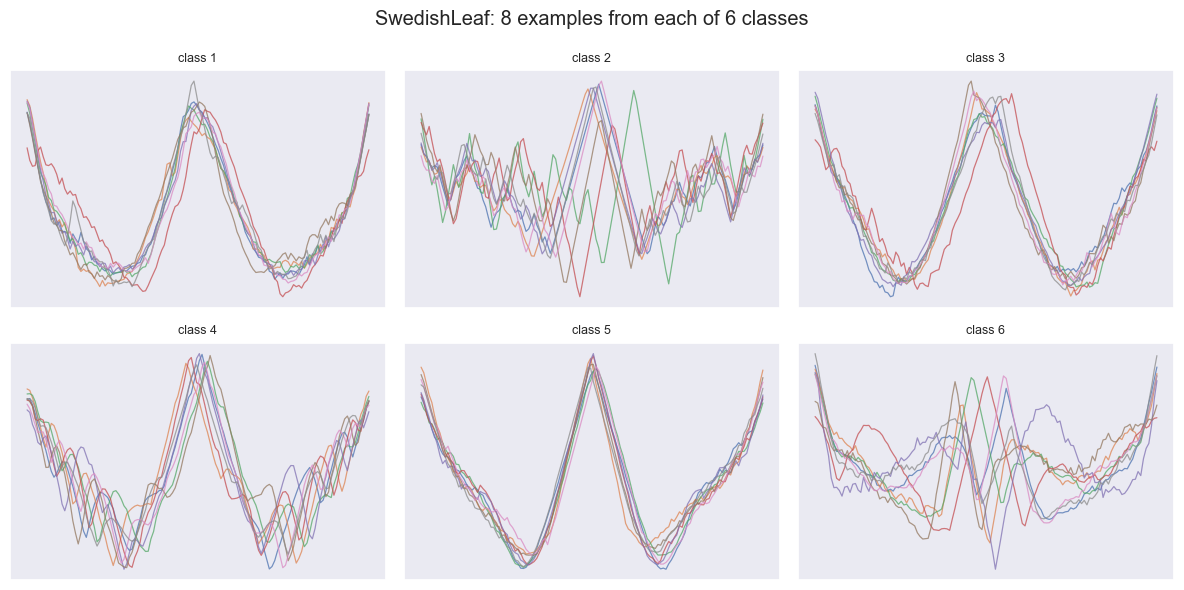

In [5]:
plot_class_overlay(X_train, y_train, class_names=class_names,
                   max_classes=6, per_class=8,
                   title=f"{TARGET_DATASET}: 8 examples from each of 6 classes")

## Two normalizations that make one backbone work everywhere

UCR datasets disagree on both **length** (15 to 2,844 steps) and **scale** (raw sensor units).
A single Transformer with fixed position embeddings cannot read that directly, so
`tutorial_ts.py` applies two transformations to every series in the archive:

1. **Resample to `SERIES_LEN = 128`** by linear interpolation over a normalized time axis. This
   changes the sampling rate, not the shape -- trend and morphology, which is what the classes
   actually differ in, survive intact. It is the sequence analogue of resizing every image to
   64x64 in the remote sensing part.
2. **Per-series z-normalization**: subtract the series' own mean, divide by its own standard
   deviation. This is the UCR convention, and it is the *right* invariance for classification --
   a leaf outline or an ECG beat means the same thing whether the sensor was offset or gained.

Note what this replaces. A forecasting setup would need a *learnable, invertible* normalization
(RevIN) because it has to put the prediction back on the original scale. A classifier never
needs to invert anything -- the label is invariant to level and scale by construction -- so a
single up-front normalization is all it takes.

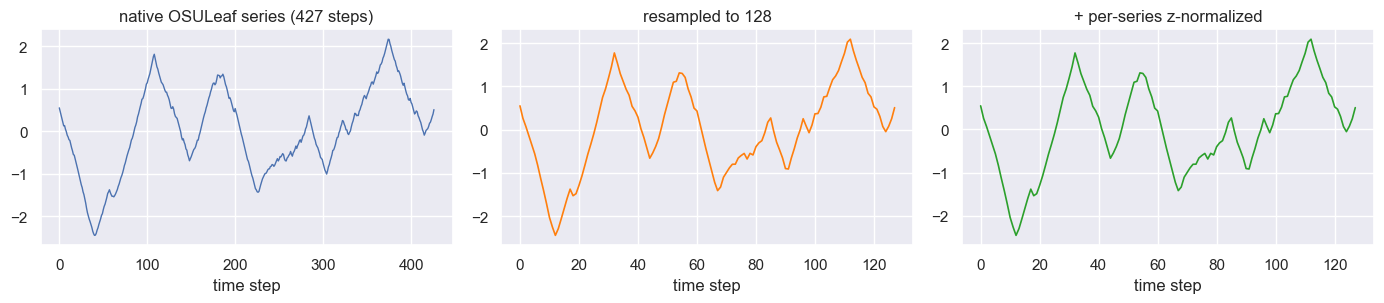

shape is preserved; only sampling rate and scale change.


In [6]:
# Take a long, unnormalized series from a different dataset and show both steps.
raw_X, raw_y = load_ucr_dataset(DATA_PATH, "OSULeaf", "train", znorm=False)
one_raw = raw_X[0]

# Reload at native length to show what resampling actually did.
import numpy as _np
native = _np.genfromtxt(os.path.join(DATA_PATH, "UCRArchive_2018", "OSULeaf",
                                     "OSULeaf_TRAIN.tsv"), delimiter="\t")[0, 1:]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(native, linewidth=1.0)
axes[0].set_title(f"native OSULeaf series ({len(native)} steps)")
axes[1].plot(resample_series(native, SERIES_LEN), linewidth=1.2, color="tab:orange")
axes[1].set_title(f"resampled to {SERIES_LEN}")
axes[2].plot(znormalize_series(resample_series(native, SERIES_LEN)), linewidth=1.2, color="tab:green")
axes[2].set_title("+ per-series z-normalized")
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout(); plt.show(); plt.close()

print(f"shape is preserved; only sampling rate and scale change.")

## The SSL view of the data: the whole archive, unlabeled

For self-supervised pretraining we **throw the labels away** and pool the `TRAIN` split of all
128 datasets into one bag of series. `UCRCorpusDataset` does this, capping how much any single
dataset may contribute so the pool is not dominated by the handful of very large members (Crop
alone has 7,200 training series; Chinatown has 20).

The target dataset's **test** split is never touched during pretraining. Its *train* split is
included with labels discarded -- standard self-supervised practice, and exactly what the remote sensing part
does, where EuroSAT's probe-training images are also part of the unlabeled pool.

Each mechanism notebook wraps this dataset with its own `transform`: two views for contrastive,
multi-crop for DINO, a plain series for MAE.

In [7]:
ssl_corpus = UCRCorpusDataset(DATA_PATH, per_dataset_cap=2000)
print(f"\nSSL pretraining corpus: {len(ssl_corpus)} series, each {tuple(ssl_corpus[0].shape)}")

# Which datasets contribute most?
top = sorted(ssl_corpus.corpus_sizes.items(), key=lambda kv: -kv[1])[:8]
print("\nlargest contributors:")
for name, n in top:
    print(f"  {name:28s} {n:5d}  ({100 * n / len(ssl_corpus):4.1f}%)")
print(f"\n{TARGET_DATASET} contributes "
      f"{ssl_corpus.corpus_sizes[TARGET_DATASET]} series "
      f"({100 * ssl_corpus.corpus_sizes[TARGET_DATASET] / len(ssl_corpus):.1f}% of the corpus)")

UCR pretraining corpus: 45192 series from 128 datasets

SSL pretraining corpus: 45192 series, each (128, 1)

largest contributors:
  Crop                          2000  ( 4.4%)
  ElectricDevices               2000  ( 4.4%)
  FordA                         2000  ( 4.4%)
  FordB                         2000  ( 4.4%)
  NonInvasiveFetalECGThorax1    1800  ( 4.0%)
  NonInvasiveFetalECGThorax2    1800  ( 4.0%)
  PhalangesOutlinesCorrect      1800  ( 4.0%)
  MelbournePedestrian           1194  ( 2.6%)

SwedishLeaf contributes 500 series (1.1% of the corpus)


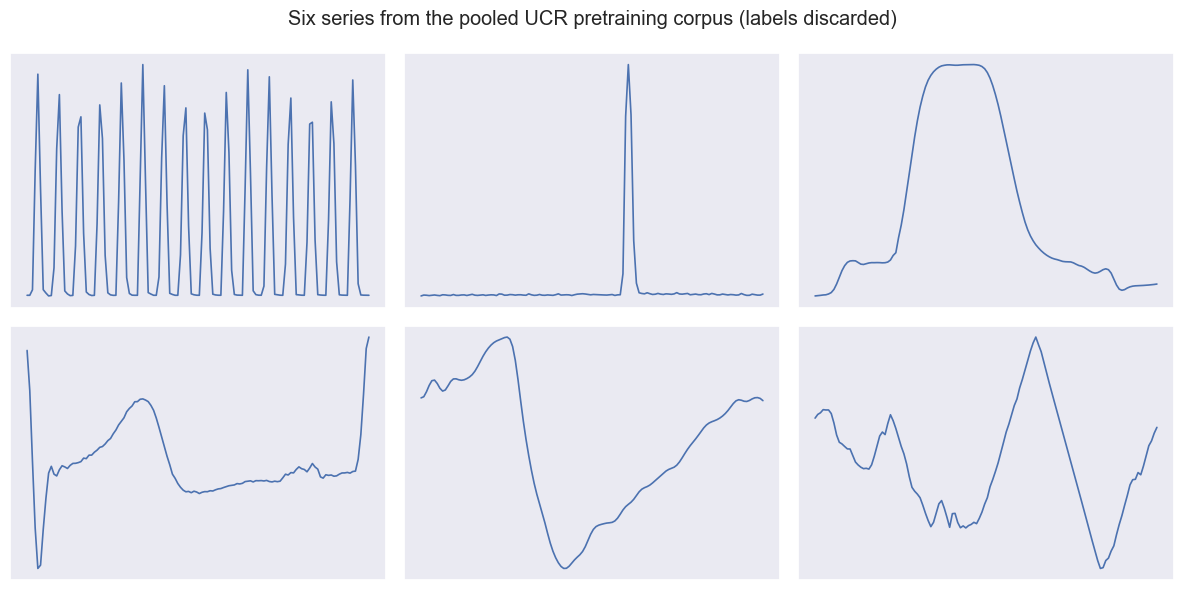

In [8]:
# A glimpse of how varied the unlabeled pool is: 6 series drawn from across the archive.
idxs = np.linspace(0, len(ssl_corpus) - 1, 6).astype(int)
sample_batch = torch.stack([ssl_corpus[i] for i in idxs])
plot_series_grid(sample_batch, n_show=6,
                 title="Six series from the pooled UCR pretraining corpus (labels discarded)")

## Time-series augmentations: a different set of nuisance transforms

The remote sensing part made a point of how remote-sensing augmentations differ from natural-image ones (free
rotation, both flips, only mild jitter). Time series shift the boundary again -- see
`build_ts_augmentations`:

| Transform | Image (EuroSAT) | Time series (UCR) |
|---|---|---|
| additive noise / jitter | mild | **yes** (sensor noise) |
| scaling / level shift | -- | **yes** (gain and offset; z-norm already removes them) |
| cutout / masking a region | -- | **yes** (contiguous time span -> bridges to MAE) |
| crop + resize | yes (RandomResizedCrop) | **yes** (sub-interval stretched back -> mild time-warp) |
| horizontal flip | yes | **no** -- time has a direction |
| vertical flip | yes (nadir view) | **no** -- the sign is physical |
| rotation | yes (no canonical orientation) | **not defined** for a 1D signal |

The two forbidden transforms are the teaching point. Reversing a series or flipping its sign
does not preserve the thing we are trying to represent -- and for several UCR datasets a
reversed series genuinely belongs to a *different class*. That is the "transformation ->
nuisance" framing from the lecture part, reaching a different answer than it did in the remote sensing part.

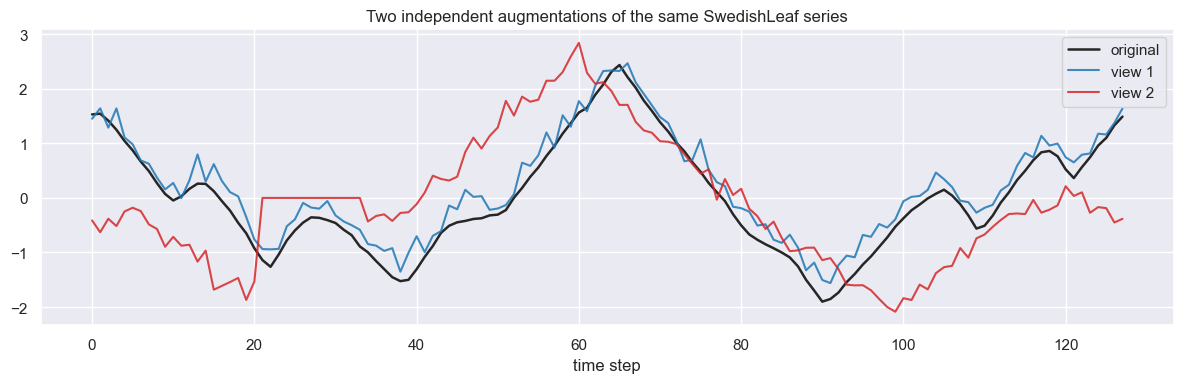

Both views keep the lobe pattern that defines the class,
while level, gain, noise and local timing all change.


In [9]:
aug = build_ts_augmentations()
two_views = ContrastiveTransformations(aug, n_views=2)

sample = torch.from_numpy(X_train[0]).float().unsqueeze(-1)   # (128, 1)
v1, v2 = two_views(sample)

plt.figure(figsize=(12, 4))
plt.plot(sample[:, 0], color="0.15", linewidth=1.8, label="original")
plt.plot(v1[:, 0], color="tab:blue", alpha=0.85, label="view 1")
plt.plot(v2[:, 0], color="tab:red", alpha=0.85, label="view 2")
plt.title(f"Two independent augmentations of the same {TARGET_DATASET} series")
plt.xlabel("time step"); plt.legend()
plt.tight_layout(); plt.show(); plt.close()

print("Both views keep the lobe pattern that defines the class,")
print("while level, gain, noise and local timing all change.")

multi-crop returns 6 views, each (128, 1)


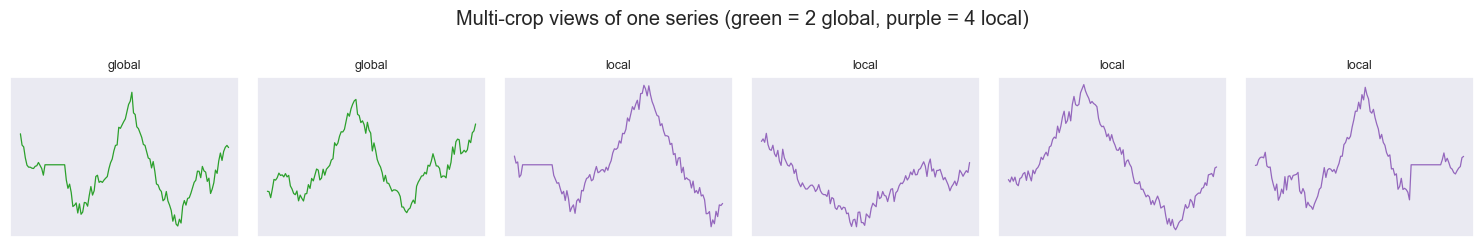

In [10]:
# DINO-style multi-crop: 2 long (global) + 4 short (local) views, all resized to SERIES_LEN
multicrop = MultiCropTransform(build_ts_augmentations(), build_ts_local_augmentations(),
                               n_global=2, n_local=4)
crops = multicrop(sample)
print(f"multi-crop returns {len(crops)} views, each {tuple(crops[0].shape)}")

fig, axes = plt.subplots(1, 6, figsize=(15, 2.5), sharey=True)
for k, (ax, crop) in enumerate(zip(axes, crops)):
    ax.plot(crop[:, 0], linewidth=0.9, color="tab:green" if k < 2 else "tab:purple")
    ax.set_title("global" if k < 2 else "local", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Multi-crop views of one series (green = 2 global, purple = 4 local)")
plt.tight_layout(); plt.show(); plt.close()

## The shared backbone: a patch Transformer

Mirroring the remote sensing part's single shared ViT-S/8, all three mechanism notebooks use one backbone:
`build_ts_encoder()`. It is **PatchTST-style** (Nie et al., 2023):

- A `(B, 128, 1)` series is cut into **8 patches** of length 16, each linearly embedded to
  dimension **128**, given a `[CLS]` token and learnable position embeddings, and run through
  **3** Transformer blocks (8 heads).
- The encoder is **channel-independent**: a `(B, L, C)` input is treated as `B x C` univariate
  series. UCR is univariate so `C = 1` and this reduces to the obvious thing -- but the contract
  is kept, because it is what would let the same encoder read multivariate series unchanged.
- `forward_features(x, pool=...)` returns one global vector per series -- the linear probe's
  input. `pool="cls"` reads the `[CLS]` token; `pool="mean"` averages the patch tokens (which is
  what MAE needs, for reasons Notebook 2 explains).

~0.6M parameters: small enough to live-train inside the tutorial, expressive enough to show
clear SSL signal at UCR scale.

Note the token budget: **8 patch tokens** here versus **64** for a 64x64 image at patch 8 in
The remote sensing part. A short 1D signal simply carries fewer tokens than an image, and that shapes several
design choices downstream -- most visibly the MAE mask ratio in Notebook 2.

In [11]:
encoder = build_ts_encoder().to(device)
n_params = sum(p.numel() for p in encoder.parameters())
print(f"TSEncoder: {n_params/1e6:.2f}M parameters, "
      f"{encoder.num_patches} patch tokens + 1 [CLS], embed_dim={encoder.embed_dim}")

train_ds = UCRDataset(DATA_PATH, TARGET_DATASET, "train")
test_ds  = UCRDataset(DATA_PATH, TARGET_DATASET, "test")
x = torch.stack([train_ds[i][0] for i in range(8)]).to(device)   # (8, 128, 1)

tokens     = encoder(x)
cls_feat   = encoder.forward_features(x, pool="cls")
mean_feat  = encoder.forward_features(x, pool="mean")
print("input           ", tuple(x.shape))
print("token sequence  ", tuple(tokens.shape), " (B*C, 1+patches, dim)")
print("[CLS] feature   ", tuple(cls_feat.shape), " (B, dim) -- contrastive/DINO readout")
print("mean-pooled     ", tuple(mean_feat.shape), " (B, dim) -- MAE readout")

TSEncoder: 0.60M parameters, 8 patch tokens + 1 [CLS], embed_dim=128


input            (8, 128, 1)
token sequence   (8, 9, 128)  (B*C, 1+patches, dim)
[CLS] feature    (8, 128)  (B, dim) -- contrastive/DINO readout
mean-pooled      (8, 128)  (B, dim) -- MAE readout


## The evaluation protocol, and a baseline to beat

Every encoder in the time series part is judged exactly the way the remote sensing part judged its encoders:

1. **Freeze** the encoder. No gradients ever flow into it.
2. Extract one feature vector per series (`forward_features`).
3. Fit a **multinomial logistic regression** on the train features.
4. Report **accuracy** on the untouched test split.

Nothing about this protocol is time-series-specific -- it is the same three lines of
scikit-learn as in the remote sensing part, which is precisely why the two tracks' tables are comparable.

Before any pretraining, let's establish the floor: what does this probe give on a **randomly
initialized** encoder? This is a real baseline, not a formality -- a random Transformer is a
random *feature map*, and a linear classifier on top of enough random features is often
surprisingly strong. Every SSL result in the following notebooks has to beat this number to
mean anything.

In [12]:
seed_everything(123)
random_encoder = build_ts_encoder().to(device)
random_encoder.eval()
for p in random_encoder.parameters():
    p.requires_grad = False

tr_f, tr_y = extract_features(random_encoder, train_ds, device, pool="cls")
te_f, te_y = extract_features(random_encoder, test_ds,  device, pool="cls")
print("features:", tr_f.shape, "->", te_f.shape)

random_acc = linear_probe_accuracy(tr_f, tr_y, te_f, te_y)
print(f"\nRandom-init frozen encoder + linear probe: {random_acc:.4f}")
print("This is the floor. Notebooks 1-3 must beat it.")

features: (500, 128) -> (625, 128)



Random-init frozen encoder + linear probe: 0.8016
This is the floor. Notebooks 1-3 must beat it.


## Recap and what comes next

We now have, all in `tutorial_ts.py`:

- The **UCR archive** downloaded, with its canonical train/test split, every series
  **resampled to 128 steps** and **per-series z-normalized**.
- An **SSL pretraining corpus**: all 128 datasets pooled, labels discarded.
- A **time-series augmentation** recipe whose *forbidden* transforms (flip, reverse) are
  themselves the teaching point.
- A shared **patch Transformer** encoder.
- The **frozen-encoder linear probe**, identical to the remote sensing part's, and a random-init floor to beat.

The next three notebooks each train this same encoder with one SSL mechanism:

| Notebook | Mechanism | Objective | Signature visual |
|---|---|---|---|
| 1 -- Contrastive (SimCLR) | instance discrimination | InfoNCE over augmented views | InfoNCE curve + embedding t-SNE |
| 2 -- Masking (MAE) | masked patch reconstruction | masked-only MSE | masked -> reconstructed -> original series |
| 3 -- Distillation (DINO) | self-distillation | teacher-student cross-entropy | patch attention over the series |

Notebook 4 then **linear-probes all three** with frozen encoders against the random-init floor,
a 1-NN Euclidean baseline and a supervised from-scratch ceiling -- the exact counterpart of
the remote sensing comparative evaluation.